In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv("D:/PROJECTS/system-log-anomaly-detection/data/raw/logging_monitoring_anomalies_dirty.csv")

C:\Users\hp\AppData\Local\Temp\ipykernel_4284\3342052113.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("D:/PROJECTS/system-log-anomaly-detection/data/raw/logging_monitoring_anomalies_dirty.csv")


In [6]:
data.head()

,Timestamp,Anomaly_ID,Anomaly_Type,Severity,Status,Source,Alert_Method,Response_Time_ms,Resolution_Time_min,Affected_Services,...,Anomaly_Duration_sec,TimeZone,User_ID,Location,Patch_Level,Service_Type,Transaction_ID,Alert_Count,Retry_Count,Escalation_Level
0,2025-01-01 00:00:00,1,Storage,Low,Open,Database,SMS,2612.0,25.0,18.0,...,43,PST,23536,APAC,4,Cache,195883,40,7,3
1,2025-01-01 00:01:00,2,Database,Medium,Closed,Server,Email,5375.0,2046.0,3.0,...,7146,IST,10030,US,0,API,952949,18,7,0
2,2025-01-01 00:02:00,3,Network,High,Acknowledged,Cloud,Webhook,7789.0,3016.0,3.0,...,1588,PST,11907,EU,12,Web,534080,32,6,1
3,2025-01-01 00:03:00,4,Application,Medium,Open,Database,SMS,361.0,757.0,9.0,...,1301,PST,32768,APAC,7,Web,452955,36,0,3
4,2025-01-01 00:04:00,5,Database,Low,Acknowledged,Firewall,SMS,935.0,1077.0,4.0,...,4336,PST,26202,APAC,14,Web,694799,39,8,2


In [7]:
data.columns

Index(['Timestamp', 'Anomaly_ID', 'Anomaly_Type', 'Severity', 'Status',
       'Source', 'Alert_Method', 'Response_Time_ms', 'Resolution_Time_min',
       'Affected_Services', 'User_Role', 'Host_IP', 'Process_ID', 'Error_Code',
       'CPU_Usage_Percent', 'Memory_Usage_MB', 'Disk_Usage_Percent',
       'Network_In_KB', 'Network_Out_KB', 'Login_Attempts',
       'Failed_Transactions', 'Anomaly_Duration_sec', 'TimeZone', 'User_ID',
       'Location', 'Patch_Level', 'Service_Type', 'Transaction_ID',
       'Alert_Count', 'Retry_Count', 'Escalation_Level'],
      dtype='object')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100200 entries, 0 to 100199
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Timestamp             100200 non-null  object 
 1   Anomaly_ID            100200 non-null  int64  
 2   Anomaly_Type          100200 non-null  object 
 3   Severity              100200 non-null  object 
 4   Status                100200 non-null  object 
 5   Source                99697 non-null   object 
 6   Alert_Method          99699 non-null   object 
 7   Response_Time_ms      99702 non-null   object 
 8   Resolution_Time_min   99699 non-null   object 
 9   Affected_Services     99702 non-null   float64
 10  User_Role             100200 non-null  object 
 11  Host_IP               100200 non-null  object 
 12  Process_ID            100200 non-null  int64  
 13  Error_Code            100200 non-null  int64  
 14  CPU_Usage_Percent     100200 non-null  float64
 15  

In [9]:
data.describe()

,Anomaly_ID,Affected_Services,Process_ID,Error_Code,CPU_Usage_Percent,Memory_Usage_MB,Disk_Usage_Percent,Network_In_KB,Network_Out_KB,Login_Attempts,Failed_Transactions,Anomaly_Duration_sec,User_ID,Patch_Level,Transaction_ID,Alert_Count,Retry_Count,Escalation_Level
count,1.002000e+05,99702.000000,1.002000e+05,100200.000000,100200.000000,100200.000000,100200.000000,100200.000000,100200.000000,100200.000000,100200.000000,100200.000000,100200.000000,100200.000000,100200.000000,100200.000000,100200.000000,100200.000000
mean,5.988725e+04,11.890022,6.040661e+04,5056.084451,50.001879,32059.267255,49.964446,500595.108832,499175.307605,24.506876,9.517016,3603.917595,25456.614192,9.515649,550592.187136,25.014511,4.505439,2.005309
std,2.228040e+05,42.414639,2.227463e+05,2856.156887,28.846073,18450.515958,28.803756,289284.715559,288347.049082,14.403543,5.767666,2076.616787,14162.981639,5.767800,259971.132447,14.109515,2.876724,1.414062
min,1.000000e+00,1.000000,1.001000e+03,100.000000,0.000000,100.000000,0.000000,2.000000,2.000000,0.000000,0.000000,1.000000,1000.000000,0.000000,100000.000000,1.000000,0.000000,0.000000
25%,2.506075e+04,5.000000,2.570875e+04,2578.750000,24.990000,16069.250000,25.160000,250115.250000,250226.500000,12.000000,5.000000,1808.000000,13206.000000,5.000000,325050.250000,13.000000,2.000000,1.000000
50%,5.011050e+04,10.000000,5.064550e+04,5053.000000,50.040000,32118.500000,49.850000,501318.500000,498289.000000,24.000000,10.000000,3592.000000,25420.000000,9.000000,550855.000000,25.000000,4.000000,2.000000
75%,7.516025e+04,15.000000,7.549700e+04,7528.000000,74.940000,48051.000000,74.760000,751349.750000,747460.250000,37.000000,15.000000,5408.250000,37797.250000,15.000000,775597.000000,37.000000,7.000000,3.000000
max,5.000000e+06,950.000000,4.999900e+06,9998.000000,100.000000,63999.000000,100.000000,999997.000000,999991.000000,49.000000,19.000000,7199.000000,49999.000000,19.000000,999986.000000,49.000000,9.000000,4.000000


In [10]:
data.isnull().sum()

Timestamp                 0
Anomaly_ID                0
Anomaly_Type              0
Severity                  0
Status                    0
Source                  503
Alert_Method            501
Response_Time_ms        498
Resolution_Time_min     501
Affected_Services       498
User_Role                 0
Host_IP                   0
Process_ID                0
Error_Code                0
CPU_Usage_Percent         0
Memory_Usage_MB           0
Disk_Usage_Percent        0
Network_In_KB             0
Network_Out_KB            0
Login_Attempts            0
Failed_Transactions       0
Anomaly_Duration_sec      0
TimeZone                  0
User_ID                   0
Location                  0
Patch_Level               0
Service_Type              0
Transaction_ID            0
Alert_Count               0
Retry_Count               0
Escalation_Level          0
dtype: int64

### Convert Timestamp

In [12]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'], errors='coerce')

In [13]:
data['Timestamp'].isnull().sum()

200

In [14]:
data[data['Timestamp'].isnull()].head()

,Timestamp,Anomaly_ID,Anomaly_Type,Severity,Status,Source,Alert_Method,Response_Time_ms,Resolution_Time_min,Affected_Services,...,Anomaly_Duration_sec,TimeZone,User_ID,Location,Patch_Level,Service_Type,Transaction_ID,Alert_Count,Retry_Count,Escalation_Level
675,NaT,676,Application,Low,Acknowledged,Firewall,Dashboard,1741.0,945.0,10.0,...,6456,EST,34310,APAC,9,Cache,353661,16,8,2
1306,NaT,1307,System,High,Open,Database,NaN,7004.0,4624.0,3.0,...,2340,EST,36345,US,12,Storage,353668,47,2,0
2176,NaT,2177,Security,High,Open,Router,Email,8500.0,1987.0,10.0,...,1017,PST,25554,EU,12,Storage,876084,31,4,2
2353,NaT,2354,Database,Low,Closed,Server,SMS,3212.0,1777.0,1.0,...,3333,PST,33405,EU,7,Cache,297057,11,5,4
2891,NaT,2892,System,Medium,Closed,Router,Dashboard,7290.0,4010.0,7.0,...,4162,PST,20975,EU,17,API,226961,4,8,1


In [15]:
data = data.dropna(subset=['Timestamp'])

In [16]:
data['Timestamp'].isnull().sum()

0

In [17]:
data['Timestamp'].dtype

dtype('<M8[ns]')

### Basic Dataset Shape

In [18]:
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

Rows: 100000
Columns: 31


### Check Duplicate Records

In [20]:
data.duplicated().sum()

4

In [22]:
data = data.drop_duplicates()

### Understand Categorical Columns

In [23]:
categorical_cols = data.select_dtypes(include='object').columns

for col in categorical_cols:
    print(col, data[col].nunique())

Anomaly_Type 12
Severity 8
Status 4
Source 6
Alert_Method 4
Response_Time_ms 11697
Resolution_Time_min 5001
User_Role 4
Host_IP 99799
TimeZone 6
Location 4
Service_Type 5


### Distribution of Anomaly Types

In [24]:
data['Anomaly_Type'].value_counts()

Anomaly_Type
Security       16859
System         16628
Database       16587
Storage        16560
Application    16551
Network        16513
NETWORK           57
APPLICATION       51
DATABASE          51
SYSTEM            49
SECURITY          48
STORAGE           42
Name: count, dtype: int64

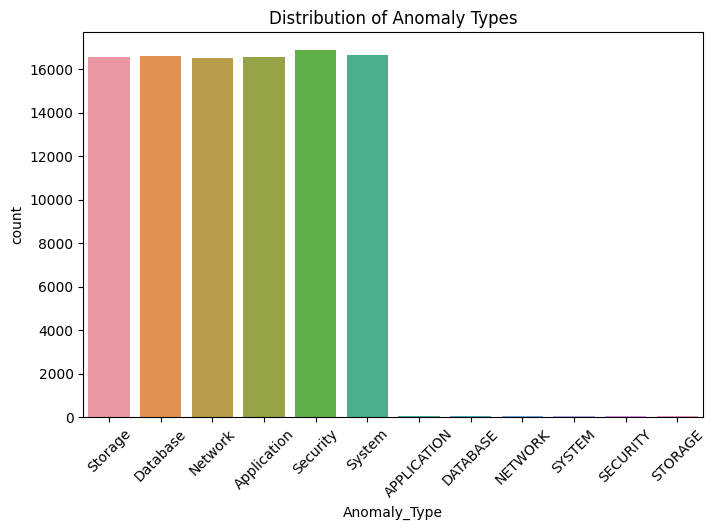

In [26]:

plt.figure(figsize=(8,5))
sns.countplot(data=data, x='Anomaly_Type')
plt.xticks(rotation=45)
plt.title("Distribution of Anomaly Types")
plt.show()

### Severity Distribution

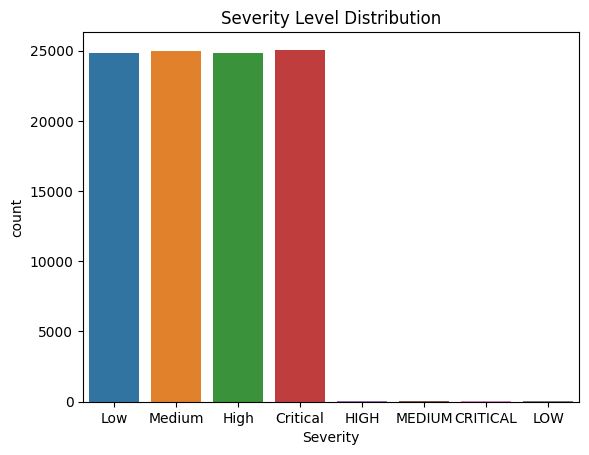

In [27]:
sns.countplot(data=data, x='Severity')
plt.title("Severity Level Distribution")
plt.show()

### Anomalies Over Time

C:\Users\hp\AppData\Local\Temp\ipykernel_4284\2831270110.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data.set_index('Timestamp')['Anomaly_ID'].resample('H').count().plot(figsize=(12,5))


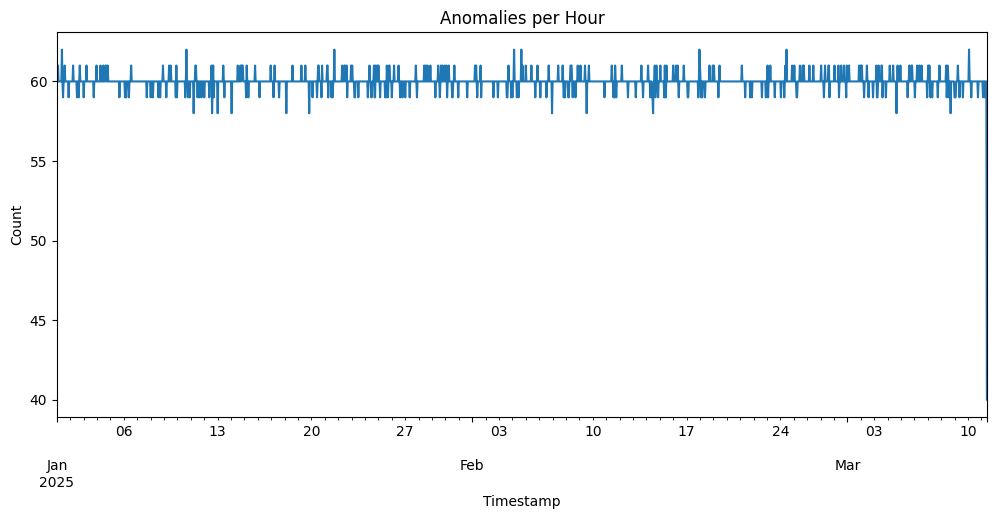

In [29]:
data.set_index('Timestamp')['Anomaly_ID'].resample('H').count().plot(figsize=(12,5))
plt.title("Anomalies per Hour")
plt.ylabel("Count")
plt.show()

### System Resource Analysis

C:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


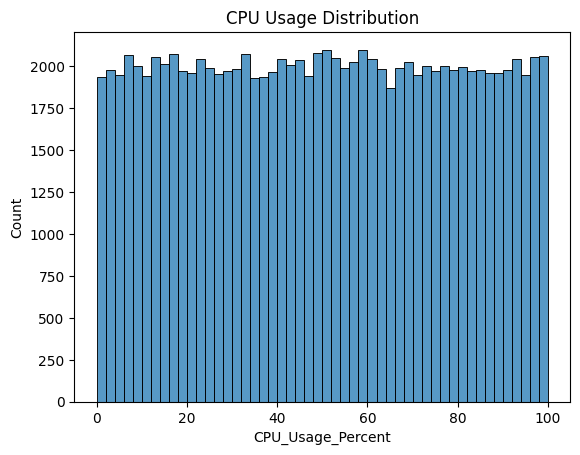

In [31]:
sns.histplot(data['CPU_Usage_Percent'], bins=50)
plt.title("CPU Usage Distribution")
plt.show()

### Correlation Heatmap

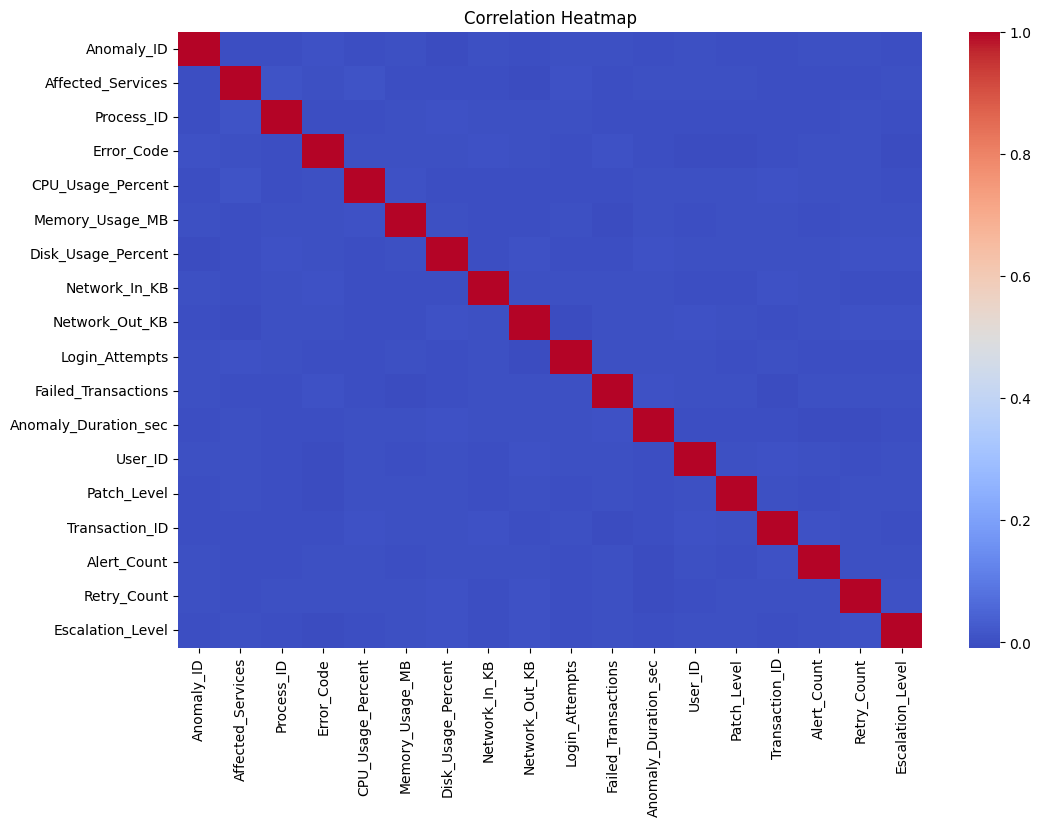

In [42]:
plt.figure(figsize=(12,8))

numeric_cols = data.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_cols.corr() ,cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Summary Insights
### Key Observations:

• Dataset contains 100k anomaly records.
• Network and Database anomalies occur most frequently.
• CPU and memory usage show correlation with anomaly duration.
• Missing values exist in alert method and source columns.